# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

# Business understanding --->> Define Data Problem (Converting Business need to Data Definition Problem)

### 1. This involves framing it as a supervised regression problem where the goal is to predict the continuous target variable, 'price', using various car attributes as features. 
### 2. The aim is to build a predictive model that quantifies the impact of these features on car pricing.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

# Steps to follow 

#### Load Initial Data: Observe the necessary datasets from the subset of data source provided by Kaggel, load them into your analytics tools, and document the collection process.
#### Describe Data: Examine the data properties: data formats, number of records, field identities (e.g., column names), and data types (numeric, nominal).
#### Explore Data: Conduct Exploratory Data Analysis (EDA) to dive deeper. This involves calculating basic statistics, visualizing distributions (histograms, scatter plots), and identifying relationships between variables.
#### Verify Data Quality: Assess the data for issues like missing values, errors, inconsistencies, or duplicates. This will help in next data preparation step

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [3]:
car_data = pd.read_csv('data/vehicles.csv')
print(car_data.head())

           id                  region  price  year manufacturer model  \
0  7222695916                prescott   6000   NaN          NaN   NaN   
1  7218891961            fayetteville  11900   NaN          NaN   NaN   
2  7221797935            florida keys  21000   NaN          NaN   NaN   
3  7222270760  worcester / central MA   1500   NaN          NaN   NaN   
4  7210384030              greensboro   4900   NaN          NaN   NaN   

  condition cylinders fuel  odometer title_status transmission  VIN drive  \
0       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   
1       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   
2       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   
3       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   
4       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   

  size type paint_color state  
0  NaN  NaN         NaN    az  
1  NaN  NaN         NaN    ar  
2 

# EDA

### 1. Mean & standard deviation indicates data is NOT normalized. It needs scaling before fitting into the model
### 2. It contains lot of nulls that need to be filled in with appropriate value 
### 3. id & VIN does not affect car price. Better to drop those columns.
### 3. Feature Engineering is needed before feeding into any model


In [4]:
car_data.info()
car_data.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


In [5]:
car_data.isnull().sum()

id                   0
region               0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
state                0
dtype: int64

In [6]:
# Drop 'id' and 'VIN' columns as they are not relevant for analysis
car_data.drop(columns=['id', 'VIN'], inplace=True)
car_data.isnull().sum()

region               0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
drive           130567
size            306361
type             92858
paint_color     130203
state                0
dtype: int64

### For old cars, price is normally determined by 
manufacturer

model

condition

age of the vehicle

milage (odometer)

title_status

fuel

### size - might not be needed as I am considering type. But let me do the transformation and then analyze

type

drive

transmission

paint_color

state


### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [11]:
# car_data['manufacturer'].fillna('Missing', inplace=True)
import warnings
warnings.filterwarnings('ignore')
car_data['manufacturer'].fillna('Missing', inplace=True)
car_data['model'].fillna('Missing', inplace=True)
print('Manufacturers:', car_data.manufacturer.nunique())
print('Models:', car_data.model.nunique())


Manufacturers: 43
Models: 29650


In [9]:
# Fill missing 'condition' values with the mode of each manufacturer-model group
car_data['condition'] = car_data.groupby(['manufacturer', 'model'])['condition'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else 'Missing')
)
print("Condition column filled with group modes")
print(car_data['condition'].isnull().sum(), "nulls remaining in condition")

# car_data[car_data['condition'] == 'Missing']

Condition column filled with group modes
0 nulls remaining in condition


In [11]:
# 1st round: Fill missing 'fuel' values with the mode of each manufacturer-model group. Similar transformation needed for title_status and paint_color.
# 2nd round: After analyzing size, type, transmission & drive need similar transformation as well

car_data['fuel'] = car_data.groupby(['manufacturer', 'model'])['fuel'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else 'Missing')
)
print("Fuel column filled with group modes")
print(car_data['fuel'].isnull().sum(), "nulls remaining in fuel")

car_data['title_status'] = car_data.groupby(['manufacturer', 'model'])['title_status'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else 'Missing')
)
print("Title Status column filled with group modes")
print(car_data['title_status'].isnull().sum(), "nulls remaining in title_status")

car_data['paint_color'] = car_data.groupby(['manufacturer', 'model'])['paint_color'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else 'Missing')
)
print("Paint Color column filled with group modes")
print(car_data['paint_color'].isnull().sum(), "nulls remaining in paint_color")

# 2nd round of filling missing values for size, type & drive
car_data['size'] = car_data.groupby(['manufacturer', 'model'])['size'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else 'Missing')
)
print("Size column filled with group modes")
print(car_data['size'].isnull().sum(), "nulls remaining in size")   

car_data['type'] = car_data.groupby(['manufacturer', 'model'])['type'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else 'Missing')
)
print("Type column filled with group modes")
print(car_data['type'].isnull().sum(), "nulls remaining in type")

car_data['drive'] = car_data.groupby(['manufacturer', 'model'])['drive'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else 'Missing')
)
print("Drive column filled with group modes")
print(car_data['drive'].isnull().sum(), "nulls remaining in drive")

car_data['transmission'] = car_data.groupby(['manufacturer', 'model'])['transmission'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else 'Missing')
)
print("Transmission column filled with group modes")
print(car_data['transmission'].isnull().sum(), "nulls remaining in transmission")


Fuel column filled with group modes
0 nulls remaining in fuel
Title Status column filled with group modes
0 nulls remaining in title_status
Paint Color column filled with group modes
0 nulls remaining in paint_color
Size column filled with group modes
0 nulls remaining in size
Type column filled with group modes
0 nulls remaining in type
Drive column filled with group modes
0 nulls remaining in drive
Transmission column filled with group modes
0 nulls remaining in transmission


In [12]:
#calculate age of the car
import datetime
current_year = datetime.datetime.now().year
print("Current Year:", current_year)
car_data['year'] = car_data.groupby(['manufacturer', 'model'])['year'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else current_year)
)
print("Year column filled with group modes")
print(car_data['year'].isnull().sum(), "nulls remaining in year")

car_data['age'] = current_year - car_data['year']
print("Age column calculated")
print(car_data['age'].isnull().sum(), "nulls remaining in age")
print(car_data[['year', 'age']].head())







Current Year: 2026
Year column filled with group modes
0 nulls remaining in year
Age column calculated
0 nulls remaining in age
     year   age
0  2005.0  21.0
1  2005.0  21.0
2  2005.0  21.0
3  2005.0  21.0
4  2005.0  21.0


In [13]:
#calculate odometer reading per MODE odometer reading for each manufacturer-model group and fill missing values
# assuming car runs on average 12,000 miles per year, we can estimate odometer reading based on age and fill missing values with group means


car_data['odometer'] = car_data.groupby(['manufacturer', 'model'])['odometer'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else 'Missing')
)


# car_data['odometer'] = car_data.groupby(['manufacturer', 'model'])['odometer'].transform(
    # lambda x: x.fillna(x.mean())
# )
print("Odometer column filled with group means")
print(car_data['odometer'].isnull().sum(), "nulls remaining in odometer")
print(car_data[car_data['odometer'] == 'Missing'].shape[0], "missing values in odometer")

# apply age based estimation for remaining missing odometer values
car_data['odometer'] = car_data.apply(
    lambda row: row['age'] * 12000 if row['odometer'] == 'Missing' else row['odometer'], axis=1
)
print("Odometer column filled with age-based estimates")
print(car_data['odometer'].isnull().sum(), "nulls remaining in odometer")
print(car_data[car_data['odometer'] == 'Missing'].shape[0], "missing values in odometer")

Odometer column filled with group means
0 nulls remaining in odometer
622 missing values in odometer
Odometer column filled with age-based estimates
0 nulls remaining in odometer
0 missing values in odometer


In [14]:
# check all missing values after feature engineering and imputation. Excluding cylinders for now
print('after all feature engineering and missing value imputation:')
car_data.isnull().sum()

after all feature engineering and missing value imputation:


region               0
price                0
year                 0
manufacturer         0
model                0
condition            0
cylinders       177678
fuel                 0
odometer             0
title_status         0
transmission         0
drive                0
size                 0
type                 0
paint_color          0
state                0
age                  0
dtype: int64

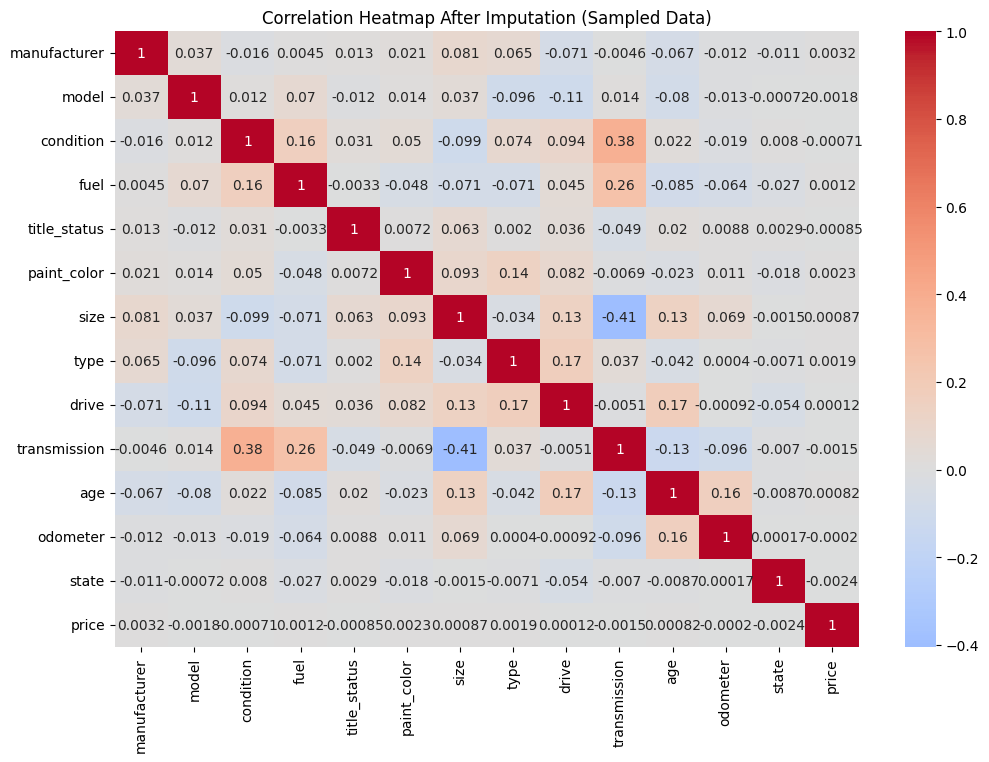

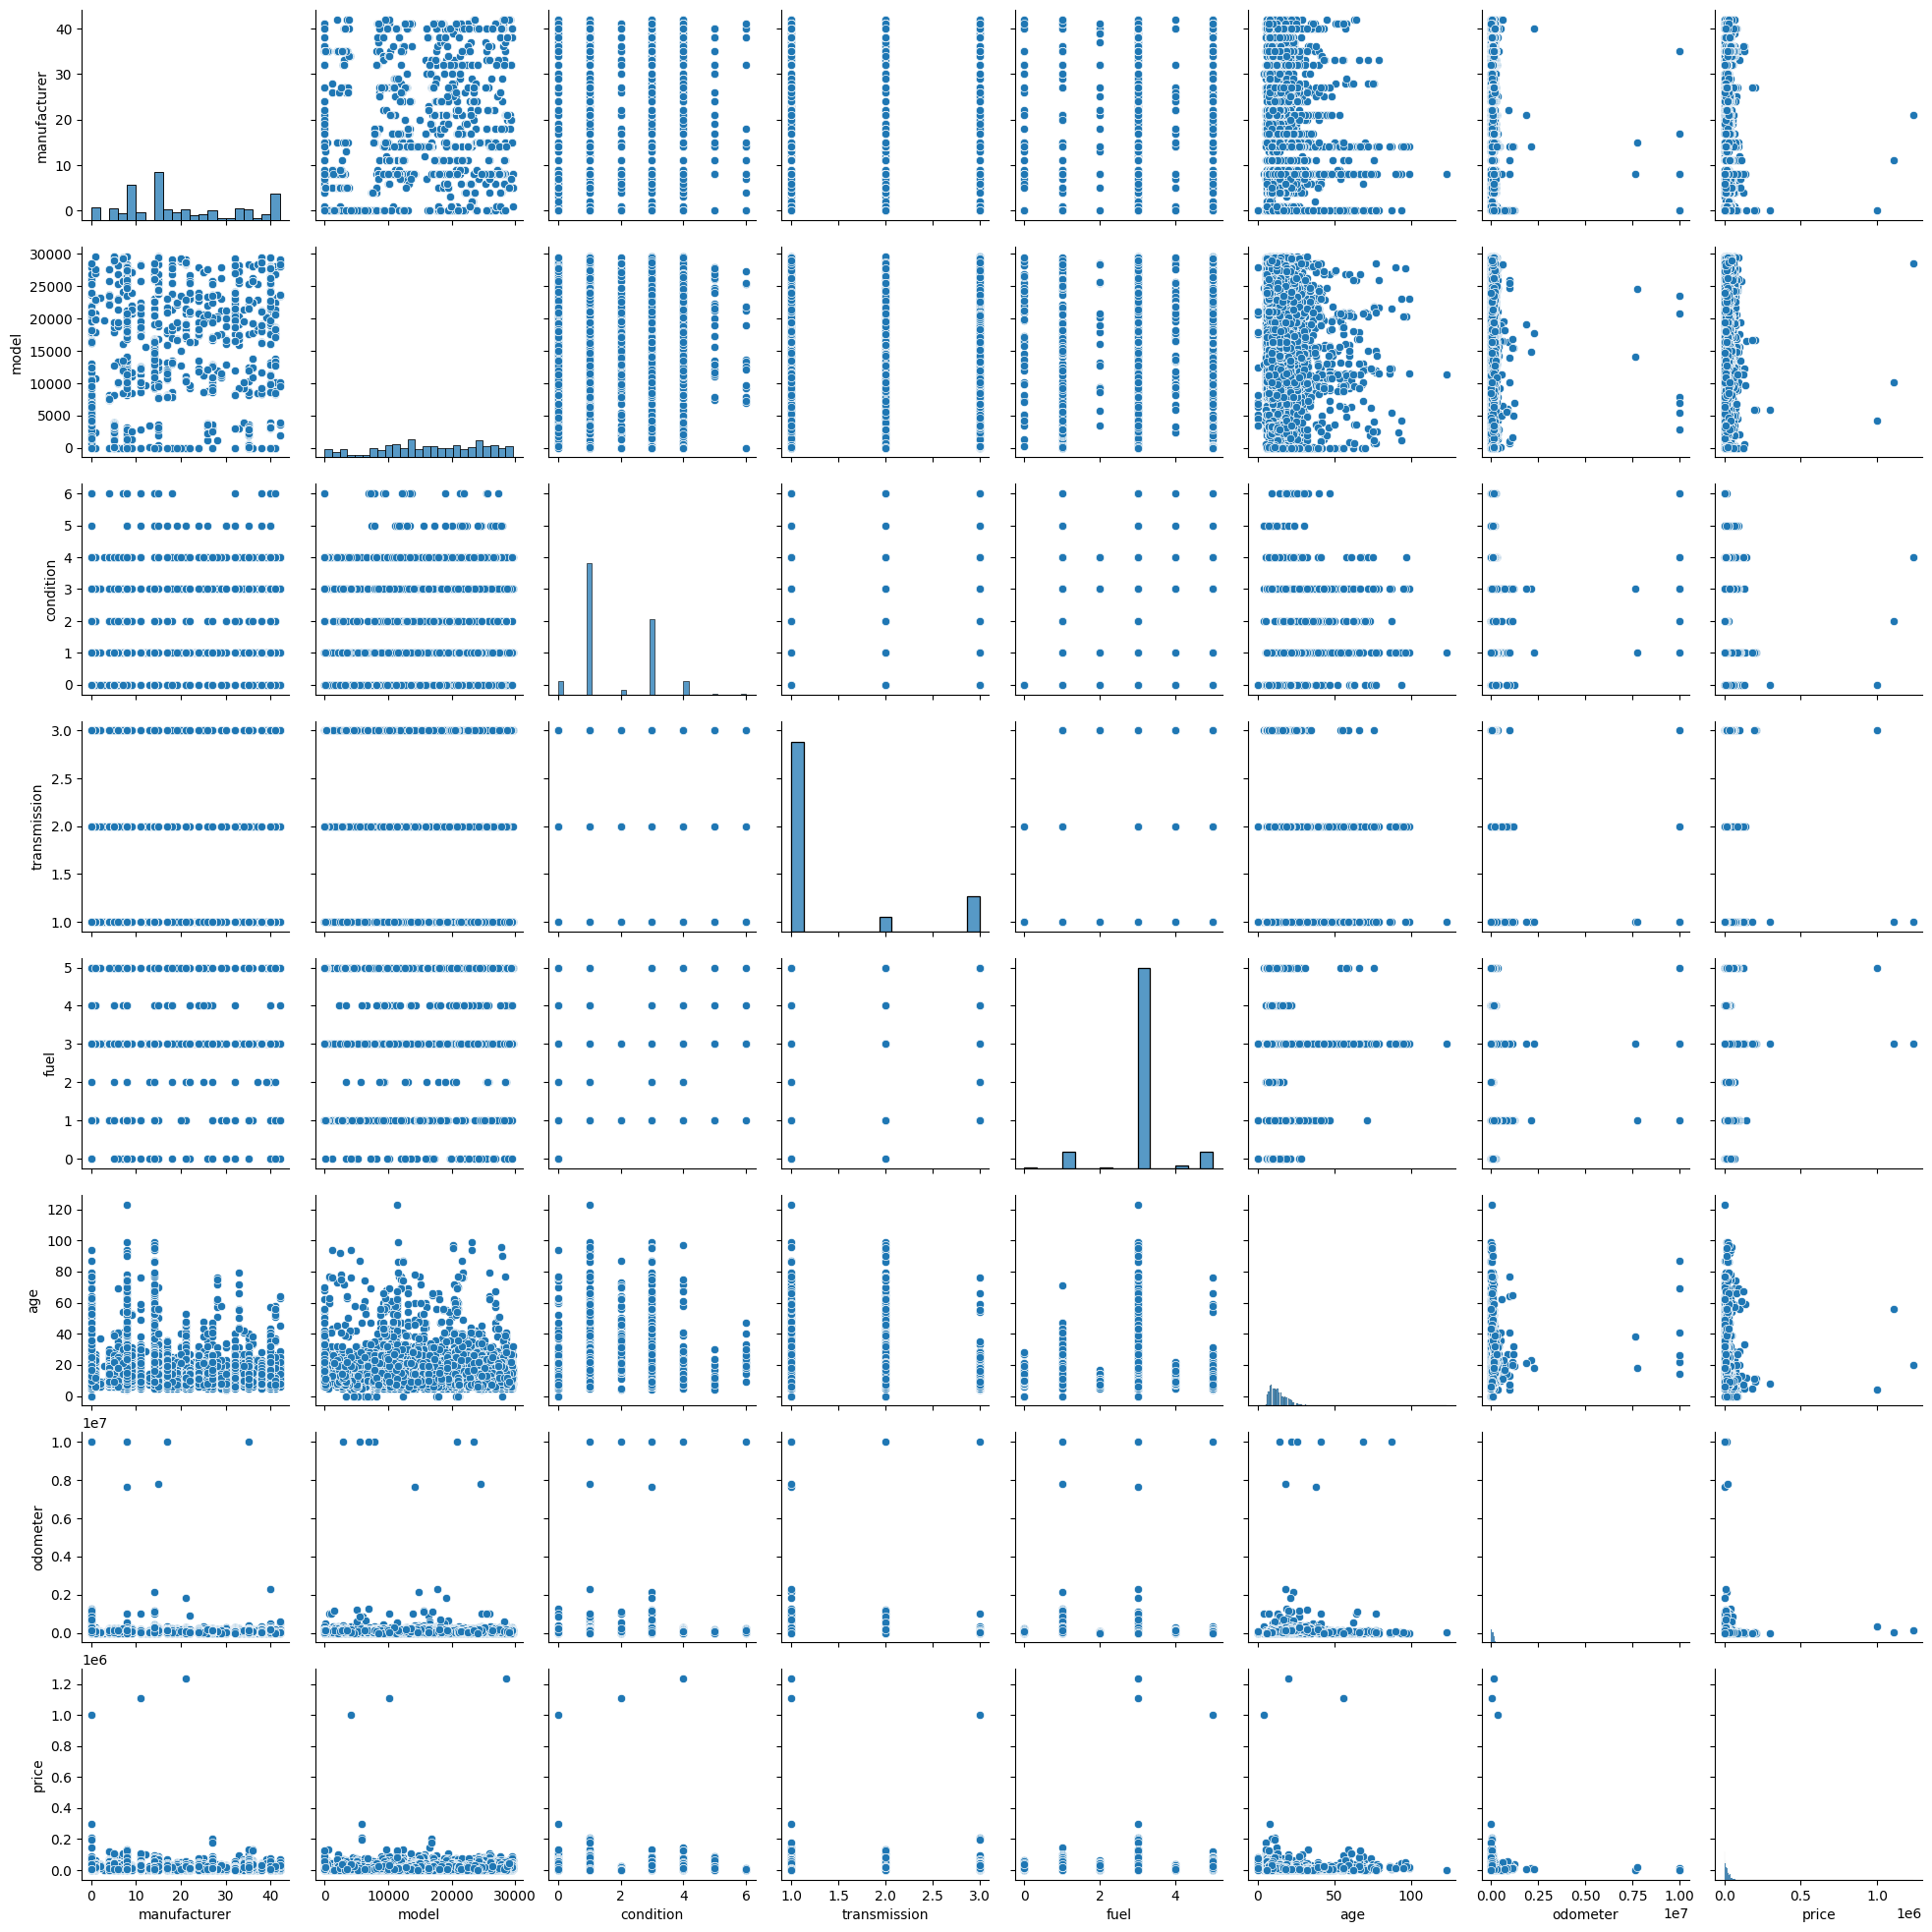

In [15]:
# draw a heatmap to visualize correlations after all feature engineering and missing value imputation
# convert all columns having value ='Missing' to numeric (-1) for heatmap visualization
# features_to_check is based on my assumption a byer will look for 
# draw pairplot to visualize relationships between key features and price, and identify potential outliers or clusters in the data. This can help in understanding the distribution of price across different categories and numerical features, and guide feature selection for modeling. However, due to the large dataset size, we will sample a subset of the data for the pairplot to ensure it runs efficiently while still providing insights into the relationships between features and price.


features_to_check = ['manufacturer', 'model', 'condition', 'fuel', 'title_status', 'paint_color', 'size', 'type', 'drive', 'transmission', 'age', 'odometer','state' ,'price']

# Replace 'Missing' with -1 in the selected features
car_data_heat_map = car_data[features_to_check].replace('Missing', -1)

# Convert categorical columns to numeric codes, keeping numeric columns as is
car_data_heat_map[features_to_check] = car_data_heat_map[features_to_check].apply(lambda x: x.astype('category').cat.codes if x.dtype == 'object' else x)

# Sample 4 0% of the data for faster correlation computation
sample_data = car_data_heat_map[features_to_check].sample(frac=0.4, random_state=42)

# Compute correlation matrix on sample

corr_matrix = sample_data.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap After Imputation (Sampled Data)')
plt.show()

# Pairplot commented out as it's too slow for large datasets
# considering key features and price for correlation analysis to identify potential relationships and multicollinearity issues before modeling
feature_for_correlation = ['manufacturer','model' ,'condition','transmission' ,'fuel','age', 'odometer', 'price']
sns.pairplot(car_data_heat_map[feature_for_correlation].sample(n=10000, random_state=42))
plt.show()

In [16]:
print('Sample data:\n',car_data[features_to_check].sample(n=5))
# print('Data types:\n', car_data[features_to_check].dtypes)
print('info:\n', car_data[features_to_check].info())
print('Description: \n',   car_data[features_to_check].describe()) # check for mean and standard deviations

Sample data:
          manufacturer                         model  condition   fuel  \
303410  mercedes-benz                 c-class c 300       good  other   
330790          buick                      lacrosse  excellent    gas   
10118             gmc  sierra 1500 4wd crew cab 143    Missing  other   
157683      chevrolet                       equinox       good    gas   
262398          honda               acord crosstour  excellent    gas   

       title_status paint_color       size     type    drive transmission  \
303410        clean       black    compact    sedan      rwd        other   
330790        clean       black  full-size    sedan      fwd    automatic   
10118         clean     Missing    Missing    other  Missing        other   
157683      rebuilt      custom  full-size      SUV      fwd    automatic   
262398        clean       white    Missing  Missing  Missing    automatic   

         age  odometer state  price  
303410   8.0   22687.0    oh  26990  
330790  

### Any SKEWED data ? 

In [17]:
def check_skewness(df):
    """
    Calculate skewness for all numeric columns
    
    Interpretation:
    - Skewness = 0: Perfectly symmetric (normal distribution)
    - -0.5 to 0.5: Fairly symmetric
    - 0.5 to 1 or -1 to -0.5: Moderately skewed
    - > 1 or < -1: Highly skewed
    """
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    skewness_dict = {}
    
    for col in numeric_cols:
        skew_value = df[col].skew()
        skewness_dict[col] = skew_value
    
    # Create DataFrame and sort by absolute skewness
    skew_df = pd.DataFrame.from_dict(
        skewness_dict, 
        orient='index', 
        columns=['Skewness']
    )
    skew_df['Abs_Skewness'] = abs(skew_df['Skewness'])
    skew_df = skew_df.sort_values('Abs_Skewness', ascending=False)
    
    return skew_df

car_data_sample = car_data.sample(n=50000, random_state=42)  # Increased sample size for better training
X = car_data_sample[features_to_check]
    
skew_results = check_skewness(X)
print(skew_results)

            Skewness  Abs_Skewness
price     223.392823    223.392823
odometer   37.652157     37.652157
age         3.530990      3.530990


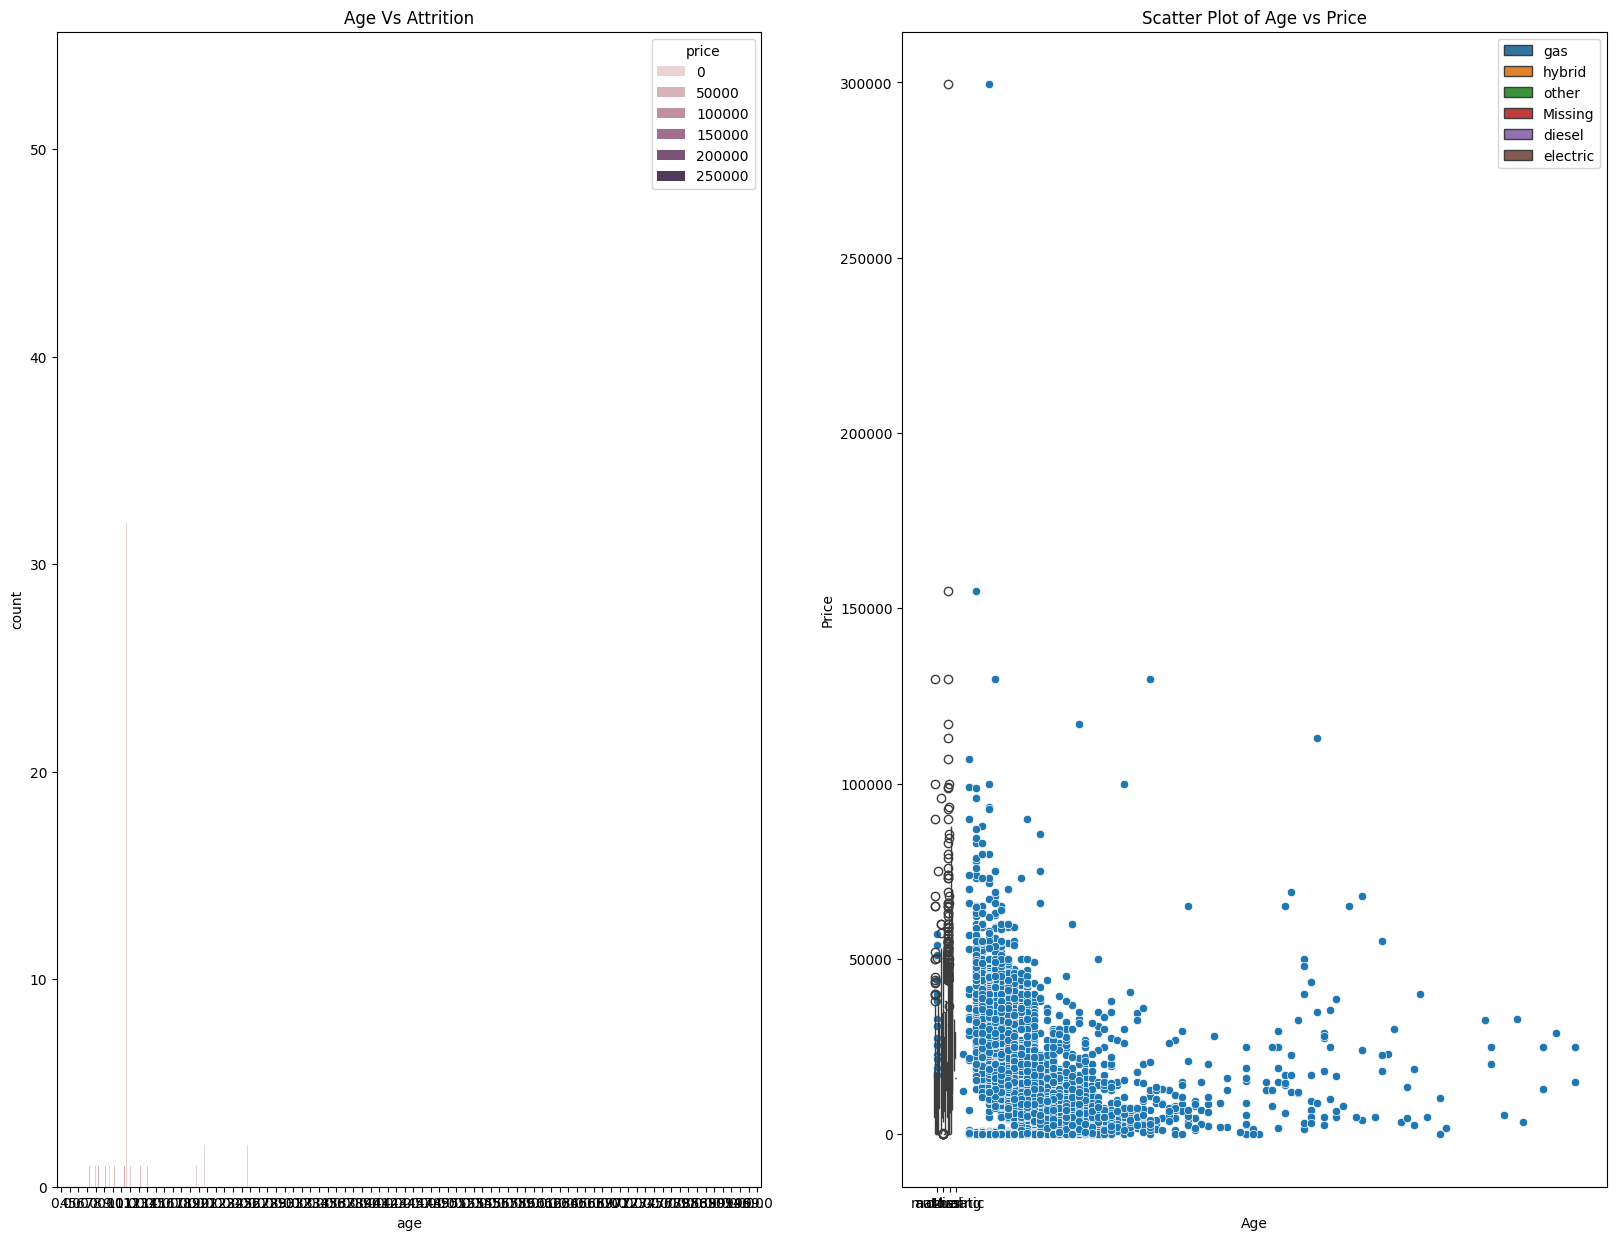

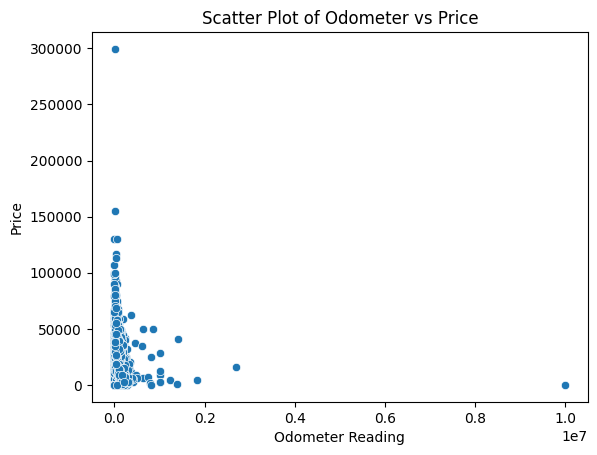

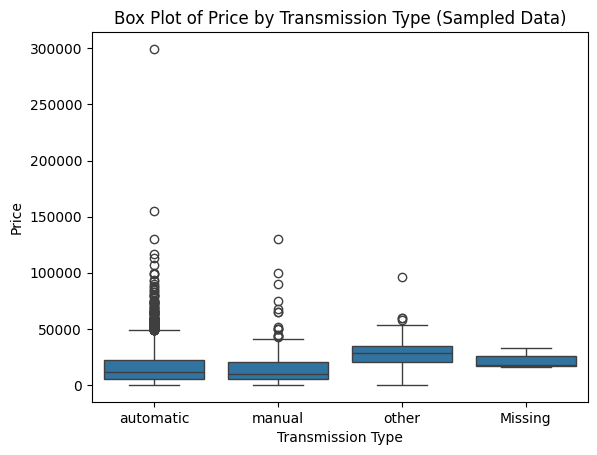

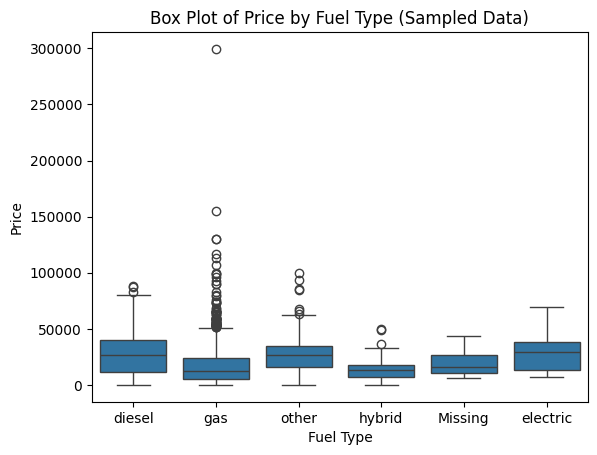

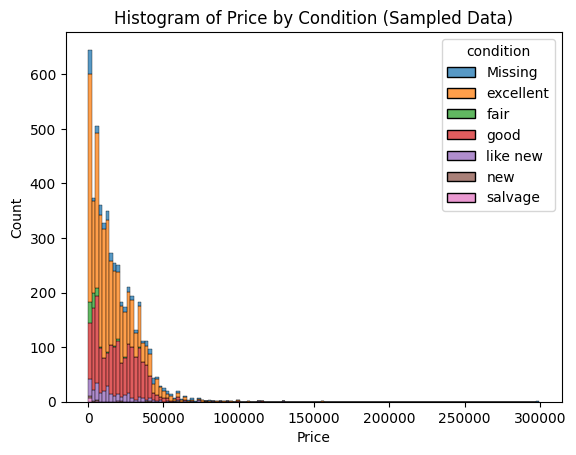

In [41]:
# use subplots to visualize relationships between condition and price, and age and price, to identify potential outliers or clusters in the data. 
# This can help in understanding how price varies with condition and age, and guide feature selection for modeling. 
# However, due to the large dataset size, we will sample a subset of the data for the scatter plots to ensure they run efficiently 
# while still providing insights into the relationships between these features and price.
# group the following plts together to visualize relationships between condition and price, and age and price, to identify potential outliers or clusters in the data. This can help in understanding how price varies with condition and age, and guide feature selection for modeling. However, due to the large dataset size, we will sample a subset of the data for the scatter plots to ensure they run efficiently while still providing insights into the relationships between these features and price.


plt.figure(figsize=(20,15))
plt.subplot(121)
plt.title('Age Vs Attrition')
sns.countplot(x='age',hue='price',data=car_data_sample.sample(n=5000, random_state=42))

plt.subplot(122)
plt.title('Transmission Vs Price')
sns.boxplot(x=car_data_sample['transmission'],y=car_data_sample['price'],hue='fuel',data=car_data_sample.sample(n=5000, random_state=42))

sns.scatterplot(data=car_data_sample.sample(n=5000, random_state=42), x='age', y='price')
plt.title('Scatter Plot of Age vs Price')
plt.xlabel('Age')
plt.ylabel('Price')
plt.show()

# plot odometer vs price to visualize relationship between mileage and price, and identify potential outliers or clusters in the data. This can help in understanding how price varies with mileage, and guide feature selection for modeling. However, due to the large dataset size, we will sample a subset of the data for the scatter plot to ensure it runs efficiently while still providing insights into the relationship between odometer reading and price.
sns.scatterplot(data=car_data_sample.sample(n=5000, random_state=42), x='odometer', y='price')
plt.title('Scatter Plot of Odometer vs Price')
plt.xlabel('Odometer Reading')
plt.ylabel('Price')
plt.show()

# plot transmission & fuel vs price to visualize how price varies across different transmission types and fuel types, and identify potential outliers or clusters in the data. This can help in understanding the impact of these categorical features on price, and guide feature selection for modeling. However, due to the large dataset size, we will sample a subset of the data for the box plots to ensure they run efficiently while still providing insights into the distribution of price across different transmission and fuel types.
sns.boxplot(data=car_data_sample.sample(n=5000, random_state=42), x='transmission', y='price')
plt.title('Box Plot of Price by Transmission Type (Sampled Data)')
plt.xlabel('Transmission Type')
plt.ylabel('Price')
plt.show()

sns.boxplot(data=car_data_sample.sample(n=5000, random_state=42), x='fuel', y='price')
plt.title('Box Plot of Price by Fuel Type (Sampled Data)')
plt.xlabel('Fuel Type')
plt.ylabel('Price')
plt.show()


# draw hist using seaborn to visualize distribution of price across different conditions and identify potential outliers or clusters in the data. This can help in understanding how price varies with condition and guide feature selection for modeling. However, due to the large dataset size, we will sample a subset of the data for the histogram to ensure it runs efficiently while still providing insights into the distribution of price across conditions.
sns.histplot(data=car_data_sample.sample(n=5000, random_state=42), x='price', hue='condition', multiple='stack')
plt.title('Histogram of Price by Condition (Sampled Data)')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()






### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

# Before modelling want to get an idea which Features are contributing most to predict price of an old car

Scaled feature shape: (50000, 66)
Total transformed features: 66
PCA components retained: 12


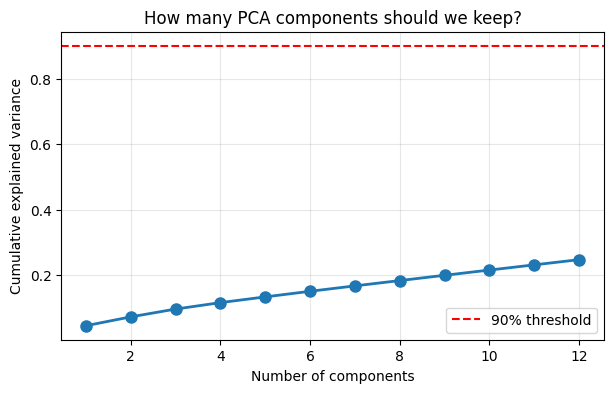

In [60]:
#PCA analysis to identify key features and reduce dimensionality for modeling
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

final_features = ['condition', 'fuel', 'transmission', 'age', 'odometer', 'state']
car_data_sample = car_data.sample(n=50000, random_state=42)  # Increased sample size for better training
X = car_data_sample[final_features]

# print('Sample data for PCA:\n', X.head())

numeric_features = ['age', 'odometer']
categorical_features = ['condition', 'fuel', 'transmission', 'state']

# Create preprocessor: StandardScale numerics, OneHotEncode categoricals
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
    ])

X_preprocessed = preprocessor.fit_transform(X)
# print('Preprocessed feature shape:', X_preprocessed.shape)

# Standardize all transformed features uniformly before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_preprocessed)
print('Scaled feature shape:', X_scaled.shape)

# Fit PCA with maximum 12 components for interpretability
pca = PCA(n_components=12)
pca.fit(X_scaled)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Get the actual transformed feature names
feature_names = preprocessor.get_feature_names_out()
print(f'Total transformed features: {len(feature_names)}')
print(f'PCA components retained: {len(explained_variance)}')

explained = pd.DataFrame({
    'component': range(1, len(explained_variance) + 1),
    'explained_variance': explained_variance,
    'cumulative_variance': cumulative_variance
})

# print("\nExplained Variance by Component:")
# print(explained)
# print(f"\nTotal variance explained by {len(explained_variance)} components: {cumulative_variance[-1]:.4f} ({cumulative_variance[-1]*100:.2f}%)")

plt.figure(figsize=(7, 4))
plt.plot(explained["component"], explained["cumulative_variance"], marker='o', linewidth=2, markersize=8)
plt.axhline(0.90, linestyle='--', label='90% threshold', color='red')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("How many PCA components should we keep?")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [43]:
print("\nPrincipal Components (loadings):")
pca_components_df = pd.DataFrame(pca.components_, columns=feature_names)
print(f"PCA components shape: {pca_components_df.shape}")
# print(pca_components_df.head())

# For example, to see the features that contribute most to the first principal component:
print("\nTop features contributing to the first principal component:")
print(pca_components_df.iloc[0].abs().sort_values(ascending=False).head(10))



Principal Components (loadings):
PCA components shape: (12, 66)

Top features contributing to the first principal component:
cat__transmission_other        0.479840
cat__transmission_automatic    0.451855
cat__condition_good            0.442724
cat__condition_excellent       0.389755
cat__fuel_other                0.322540
cat__fuel_gas                  0.263806
num__age                       0.089333
num__odometer                  0.065442
cat__transmission_manual       0.052846
cat__fuel_electric             0.046238
Name: 0, dtype: float64


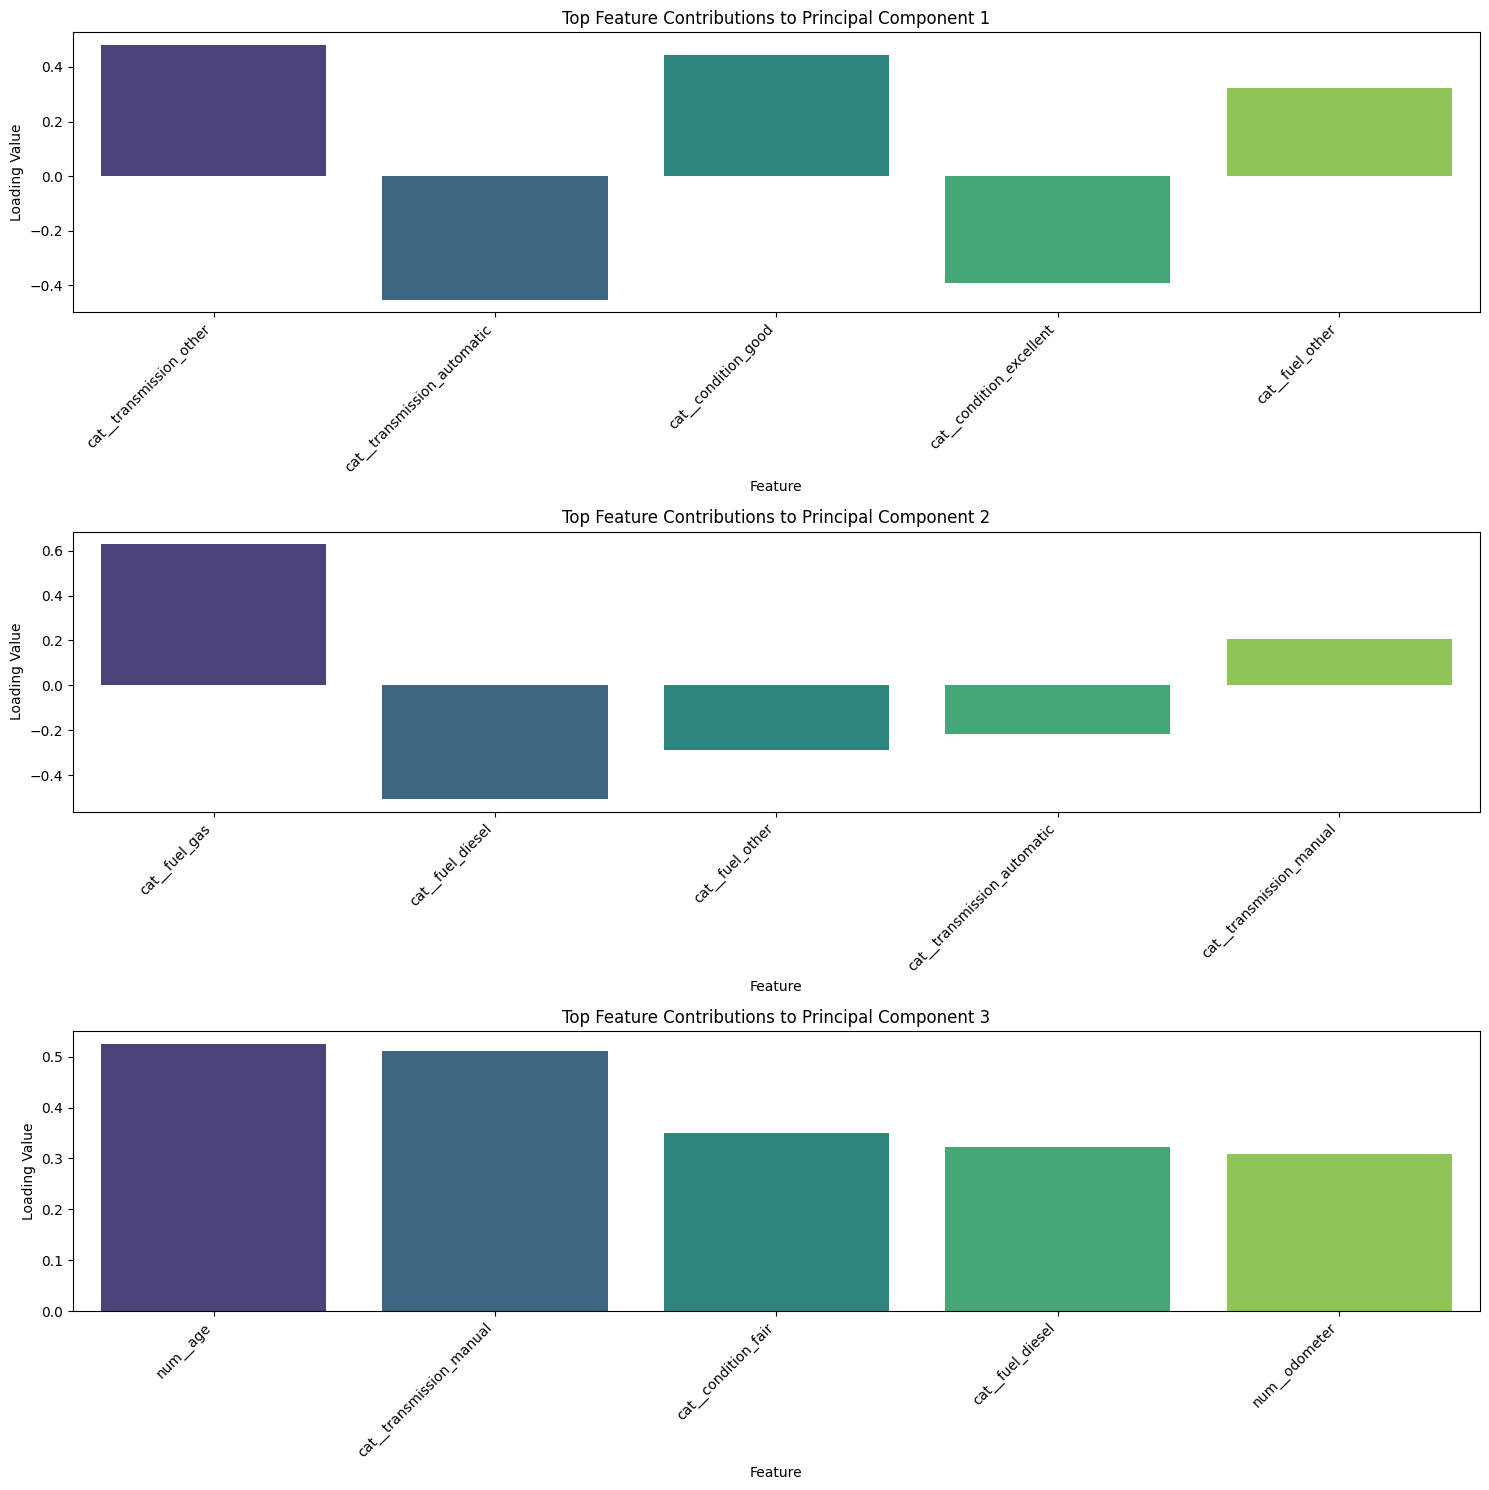

In [46]:
suppress_warnings = True
if suppress_warnings:
    import warnings
    warnings.filterwarnings('ignore')
    
num_components_to_plot = 3 # Let me check for first 3 components to understand key features contributing to variance in the data, you can adjust this number based on how many components you want to analyze in depth

plt.figure(figsize=(15, 5 * num_components_to_plot))

for i in range(num_components_to_plot):
    # Get the loadings for the current principal component
    component_loadings = pca_components_df.iloc[i]

    # Sort by absolute value to find the most influential features
    sorted_loadings = component_loadings.abs().sort_values(ascending=False)

    # Get the top N features (e.g., top 5) and their actual loadings
    top_features = sorted_loadings.head(5).index
    top_loadings = component_loadings[top_features]

    plt.subplot(num_components_to_plot, 1, i + 1)
    sns.barplot(x=top_loadings.index, y=top_loadings.values, palette='viridis')
    plt.title(f'Top Feature Contributions to Principal Component {i + 1}')
    plt.xlabel('Feature')
    plt.ylabel('Loading Value')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

plt.show()

### PCA indicates following features are more significant to predict used car price for the currrent dataset with categorical features
transmission

condition

fuel

age

odometer


### The following 4 features seems to have little impact on used car price

manufacturer

model

state

## START MODELLING


In [47]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error as mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector

In [48]:
pca_final_features = ['condition','transmission' ,'fuel','age', 'odometer', 'state']  # Added back odometer and state
y = np.log1p(car_data_sample['price'])  # Log transform price to handle skewness
# car_data_sample['odometer'] = np.log1p(car_data_sample['odometer'])  # Log transform odometer to handle skewness
X = car_data_sample[pca_final_features]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [49]:
# Create a pipeline that includes preprocessing, PCA as a dimensionality reduction technique, and the regression model
full_pipeline = Pipeline(steps=[
    ('preprocessor', ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), ['age', 'odometer']),
            ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), ['condition', 'transmission', 'fuel', 'state']),
        ])),
    ('pca', PCA(n_components=0.9)),# from PCA analysis it could require more components to capture 90% variance, but we will start with 12 for interpretability
    ('model', LinearRegression())
])


# Corrected param_grid
param_grid = [
    {'model': [LinearRegression()]},
    {'model': [Ridge()], 'model__alpha': [0.1, 0.5, 1.0]},
    {'model': [Lasso()], 'model__alpha': [0.1, 0.5, 1.0]}
]

In [50]:
grid_search = GridSearchCV(estimator=full_pipeline, param_grid=param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['age',
                                                                          'odometer']),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         ['condition',
                                                                          'transmission',
                                                                          'fuel',
                                                                          'state'])])),
                                       ('pca', PCA(n_components=0.9)),
                                       ('model', LinearRegression())]),
             param_grid=[{'model': [LinearRegression()]},
                         {'model': [Ridge()], 'model__alpha': [0.1, 0.5, 1.0]},
                         {'model': [Lasso()], 'model__alpha': [0.1, 0.5, 1.0]}],
             scoring='r2')

In [51]:
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation R^2 score: ", grid_search.best_score_)
column_of_interest = grid_search.best_estimator_.named_steps['preprocessor'].get_feature_names_out()
# print("Selected features: ", column_of_interest)

best_model = grid_search.best_estimator_
print("Best model: ", best_model)
y_pred_test = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

# Since we used log transformation, convert back to original scale for MSE
y_pred_test_orig = np.expm1(y_pred_test)
y_pred_train_orig = np.expm1(y_pred_train)
y_test_orig = np.expm1(y_test)
y_train_orig = np.expm1(y_train)

mse_test = mean_squared_error(y_test_orig, y_pred_test_orig)
mse_train = mean_squared_error(y_train_orig, y_pred_train_orig)
print("Mean Squared Error with PCA Feature Selection on training set: ", mse_train)
print("Mean Squared Error with PCA Feature Selection on test set: ", mse_test)

Best parameters found:  {'model': Ridge(), 'model__alpha': 1.0}
Best cross-validation R^2 score:  0.05499808231558767
Best model:  Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'odometer']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['condition', 'transmission',
                                                   'fuel', 'state'])])),
                ('pca', PCA(n_components=0.9)), ('model', Ridge())])
Mean Squared Error with PCA Feature Selection on training set:  30884010930336.04
Mean Squared Error with PCA Feature Selection on test set:  325986526.57310

### Compare Polynomial Feature selector with sequential selector

In [52]:
from sklearn.preprocessing import PolynomialFeatures

pca_final_features = ['condition','transmission' ,'fuel','age', 'odometer', 'state']  # Added back odometer and state
y = np.log1p(car_data_sample['price'])  # Log transform price to handle skewness
# car_data_sample['odometer'] = np.log1p(car_data_sample['odometer'])  # Log transform odometer to handle skewness
X = car_data_sample[pca_final_features]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


full_pipeline_poly = Pipeline(steps=[
    ('preprocessor', ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), ['age', 'odometer']),
            ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), ['condition', 'transmission', 'fuel', 'state']),
        ])),
    # ('pca', PCA(n_components=12)),
    ('scaler', StandardScaler()),
    ('selector', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', LinearRegression()) # placeholder estimator
])
param_grid = [
    {'model': [LinearRegression()]},
    {'model': [Ridge()], 'model__alpha': [0.1,0.5,1.0]},
    {'model': [Lasso()], 'model__alpha': [0.1,0.5,1.0]}
]



grid_search_poly = GridSearchCV(estimator=full_pipeline_poly, param_grid=param_grid, cv=4, scoring='r2', refit=True)

grid_search_poly.fit(X_train, y_train)

GridSearchCV(cv=4,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['age',
                                                                          'odometer']),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         ['condition',
                                                                          'transmission',
                                                                          'fuel',
                                                                          'state'])])),
                                       ('scaler', StandardScaler()),
                                       ('selector',
                                        PolynomialFeatures(include_bias=False)),
                                       ('model', LinearRegression())]),
             param_grid=[{'model': [LinearRegression()]},
                         {'model': [Ridge()], 'model__alpha': [0.1, 0.5, 1.0]},
                         {'model': [Lasso()], 'model__alpha': [0.1, 0.5, 1.0]}],
             scoring='r2')

In [53]:
y_pred_train_poly = grid_search_poly.predict(X_train)
y_pred_test_poly = grid_search_poly.predict(X_test)
y_pred_train_orig = np.expm1(y_pred_train_poly) # Convert back to original scale
y_pred_test_orig = np.expm1(y_pred_test_poly)

y_test_orig = np.expm1(y_test) # Convert back to original scale
y_train_orig = np.expm1(y_train)

mse_test_poly = mean_squared_error(y_test_orig, y_pred_test_orig)

mse_train_poly = mean_squared_error(y_train_orig, y_pred_train_orig) 
print("Best parameters found for polynomial regression: ", grid_search_poly.best_params_)
print("Best cross-validation R^2 score for polynomial regression: ", grid_search_poly.best_score_)
print("Mean Squared Error on training set for polynomial regression: ", mse_train_poly)
print("Mean Squared Error on test set for polynomial regression: ", mse_test_poly)
# print("features_to_check: ", grid_search_poly.best_estimator_.named_steps['selector'].get_feature_names_out() )


Best parameters found for polynomial regression:  {'model': Lasso(), 'model__alpha': 0.1}
Best cross-validation R^2 score for polynomial regression:  0.0830109026645191
Mean Squared Error on training set for polynomial regression:  30883976278358.79
Mean Squared Error on test set for polynomial regression:  318770548.042995


### Try with SequentialFeatureSelector

In [54]:
pca_final_features = ['condition','transmission' ,'fuel','age', 'odometer', 'state']  # Added back odometer and state
y = np.log1p(car_data_sample['price'])  # Log transform price to handle skewness
# car_data_sample['odometer'] = np.log1p(car_data_sample['odometer'])  # Log transform odometer to handle skewness
X = car_data_sample[pca_final_features]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


full_pipeline_seq = Pipeline(steps=[
    ('preprocessor', ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), ['age', 'odometer']),
            ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), ['condition', 'transmission', 'fuel', 'state']),
        ])),
    # ('pca', PCA(n_components=12)),
    ('scaler', StandardScaler()),
    # ('selector', PolynomialFeatures(degree=2, include_bias=False)),
    ('selector', SequentialFeatureSelector(LinearRegression(), n_features_to_select=5, direction='forward')),
    ('model', LinearRegression()) # placeholder estimator
])
param_grid = [
    {'model': [LinearRegression()]},
    {'model': [Ridge()], 'model__alpha': [0.1,0.5,1.0]},
    {'model': [Lasso()], 'model__alpha': [0.1,0.5,1.0]}
]


# refit=True to automatically refit the best model when you directly call predict on the grid search object after fitting on unknown data
grid_search_seq = GridSearchCV(estimator=full_pipeline_seq, param_grid=param_grid, cv=3, scoring='r2', refit=True) 


grid_search_seq.fit(X_train, y_train)


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['age',
                                                                          'odometer']),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         ['condition',
                                                                          'transmission',
                                                                          'fuel',
                                                                          'state'])])),
                                       ('scaler', StandardScaler()),
                                       ('selector',
                                        SequentialFeatureSelector(estimator=LinearRegression(),
                                                                  n_features_to_select=5)),
                                       ('model', LinearRegression())]),
             param_grid=[{'model': [LinearRegression()]},
                         {'model': [Ridge()], 'model__alpha': [0.1, 0.5, 1.0]},
                         {'model': [Lasso()], 'model__alpha': [0.1, 0.5, 1.0]}],
             scoring='r2')

In [55]:
y_pred_train_seq = grid_search_seq.predict(X_train)
y_pred_test_seq = grid_search_seq.predict(X_test)
y_pred_train_orig = np.expm1(y_pred_train_seq) # Convert back to original scale
y_pred_test_orig = np.expm1(y_pred_test_seq)

y_test_orig = np.expm1(y_test) # Convert back to original scale
y_train_orig = np.expm1(y_train)

mse_test_seq = mean_squared_error(y_test_orig, y_pred_test_orig)

mse_train_seq = mean_squared_error(y_train_orig, y_pred_train_orig) 
print("Best parameters found for sequential regression: ", grid_search_seq.best_params_)
print("Best cross-validation R^2 score for sequential regression: ", grid_search_seq.best_score_)
print("Mean Squared Error on training set for sequential regression: ", mse_train_seq)
print("Mean Squared Error on test set for sequential regression: ", mse_test_seq)
# print("features_to_check: ", grid_search_seq.best_estimator_.named_steps['selector'].get_feature_names_out() )


Best parameters found for sequential regression:  {'model': Ridge(), 'model__alpha': 1.0}
Best cross-validation R^2 score for sequential regression:  0.05011122962536041
Mean Squared Error on training set for sequential regression:  30883944114726.297
Mean Squared Error on test set for sequential regression:  332517267.61842513


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

#### **TESTING ON TOTALLY UNKNOWN DATA**
#### **Mocked up to mimic a scenario : THREE  used cars added to the inventory**

Testing on mockedup data for 3 cars and below evaluation results shows polynomial model predicts beter price

car 1   : year = 2020 model ,condition=bad, odometer = 5000 

car 2   : year = 2019 model ,condition=good, odometer = 100223 

car 3   : year = 2000 model ,condition=bad, odometer = 200899 

Predicted prices for unknown test data using polynomial regression:  [ 3287.64044477 24483.75071341  3019.24319896]



In [56]:
df_unknown_test = pd.read_csv('data/vehicle_unknown_test_data.csv')


In [57]:
# 1st round: Fill missing 'fuel' values with the mode of each manufacturer-model group. Similar transformation needed for title_status and paint_color.
# 2nd round: After analyzing size, type, transmission & drive need similar transformation as well

df_unknown_test['fuel'] = df_unknown_test.groupby(['manufacturer', 'model'])['fuel'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else 'Missing')
)
print("Fuel column filled with group modes")
print(df_unknown_test['fuel'].isnull().sum(), "nulls remaining in fuel")

df_unknown_test['title_status'] = df_unknown_test.groupby(['manufacturer', 'model'])['title_status'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else 'Missing')
)
print("Title Status column filled with group modes")
print(df_unknown_test['title_status'].isnull().sum(), "nulls remaining in title_status")

df_unknown_test['paint_color'] = df_unknown_test.groupby(['manufacturer', 'model'])['paint_color'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else 'Missing')
)
print("Paint Color column filled with group modes")
print(df_unknown_test['paint_color'].isnull().sum(), "nulls remaining in paint_color")

# 2nd round of filling missing values for size, type & drive
df_unknown_test['size'] = df_unknown_test.groupby(['manufacturer', 'model'])['size'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else 'Missing')
)
print("Size column filled with group modes")
print(df_unknown_test['size'].isnull().sum(), "nulls remaining in size")   

df_unknown_test['type'] = df_unknown_test.groupby(['manufacturer', 'model'])['type'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else 'Missing')
)
print("Type column filled with group modes")
print(df_unknown_test['type'].isnull().sum(), "nulls remaining in type")

df_unknown_test['drive'] = df_unknown_test.groupby(['manufacturer', 'model'])['drive'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else 'Missing')
)
print("Drive column filled with group modes")
print(df_unknown_test['drive'].isnull().sum(), "nulls remaining in drive")

df_unknown_test['transmission'] = df_unknown_test.groupby(['manufacturer', 'model'])['transmission'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else 'Missing')
)
print("Transmission column filled with group modes")
print(df_unknown_test['transmission'].isnull().sum(), "nulls remaining in transmission")


Fuel column filled with group modes
0 nulls remaining in fuel
Title Status column filled with group modes
0 nulls remaining in title_status
Paint Color column filled with group modes
0 nulls remaining in paint_color
Size column filled with group modes
0 nulls remaining in size
Type column filled with group modes
0 nulls remaining in type
Drive column filled with group modes
0 nulls remaining in drive
Transmission column filled with group modes
0 nulls remaining in transmission


In [58]:
#calculate age of the car
import datetime
current_year = datetime.datetime.now().year
print("Current Year:", current_year)
df_unknown_test['year'] = df_unknown_test.groupby(['manufacturer', 'model'])['year'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else current_year)
)
print("Year column filled with group modes")
print(df_unknown_test['year'].isnull().sum(), "nulls remaining in year")

df_unknown_test['age'] = current_year - df_unknown_test['year']
print("Age column calculated")
print(df_unknown_test['age'].isnull().sum(), "nulls remaining in age")
print(df_unknown_test[['year', 'age']].head())

#calculate odometer reading per mean odometer reading for each manufacturer-model group and fill missing values
# assuming car runs on average 12,000 miles per year, we can estimate odometer reading based on age and fill missing values with group means


df_unknown_test['odometer'] = df_unknown_test.groupby(['manufacturer', 'model'])['odometer'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else 'Missing')
)


# car_data['odometer'] = car_data.groupby(['manufacturer', 'model'])['odometer'].transform(
    # lambda x: x.fillna(x.mean())
# )
print("Odometer column filled with group means")
print(df_unknown_test['odometer'].isnull().sum(), "nulls remaining in odometer")
print(df_unknown_test[df_unknown_test['odometer'] == 'Missing'].shape[0], "missing values in odometer")

# apply age based estimation for remaining missing odometer values
df_unknown_test['odometer'] = df_unknown_test.apply(
    lambda row: row['age'] * 12000 if row['odometer'] == 'Missing' else row['odometer'], axis=1
)
print("Odometer column filled with age-based estimates")
print(df_unknown_test['odometer'].isnull().sum(), "nulls remaining in odometer")
print(df_unknown_test[df_unknown_test['odometer'] == 'Missing'].shape[0], "missing values in odometer")







Current Year: 2026
Year column filled with group modes
0 nulls remaining in year
Age column calculated
0 nulls remaining in age
   year  age
0  2020    6
1  2019    7
2  2000   26
Odometer column filled with group means
0 nulls remaining in odometer
0 missing values in odometer
Odometer column filled with age-based estimates
0 nulls remaining in odometer
0 missing values in odometer


In [59]:
# transform unknown test data using the same preprocessing steps and predict prices using the best model from grid search
final_unknown_test_data_featured = ['condition','transmission' ,'fuel','age', 'odometer', 'state']

full_pipeline_unknown = Pipeline(steps=[
    ('preprocessor', ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), ['age', 'odometer']),
            ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), ['condition', 'transmission', 'fuel', 'state']),
        ]))
])


full_pipeline_unknown.fit(X_train[final_unknown_test_data_featured], y_train)


X_unknown_test = df_unknown_test[final_unknown_test_data_featured]
y_unknown_test_pred = grid_search.predict(X_unknown_test)
print("Predicted prices for unknown test data: ", np.expm1(y_unknown_test_pred))

# grid_search_seq.fit(X_train[final_unknown_test_data_featured], y_train)
y_unknown_test_pred_seq = grid_search_seq.predict(X_unknown_test)
print("Predicted prices for unknown test data using sequential feature selection: ", np.expm1(y_unknown_test_pred_seq))

# grid_search_poly.fit(X_train[final_unknown_test_data_featured], y_train)
y_unknown_test_pred_poly = grid_search_poly.predict(X_unknown_test)

print("Predicted prices for unknown test data using polynomial regression: ", np.expm1(y_unknown_test_pred_poly))



Predicted prices for unknown test data:  [14969.68081404 19983.60977361  9916.21804841]
Predicted prices for unknown test data using sequential feature selection:  [14141.410206   22302.24747116 14141.410206  ]
Predicted prices for unknown test data using polynomial regression:  [ 3287.64044477 24483.75071341  3019.24319896]


### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

### **My recommendation to dealer**

**They should focus on the following key features for used car**

Car condition

Year built (age of the vehicle)

Milage(odometer)


The dealers can also think of extending their conversation on vehicle transmission & fuel (like gas/ hybrid/electric) to customers to influence their buying decision on used cars.

When dealer are bying used cars for future resell, they can consider these key features that affects the used car selling price. 

